Mobile net V3

Using device: cuda


Epoch 1: 100%|██████████| 269/269 [02:17<00:00,  1.95it/s]


Train Acc: 34.28% | Val Acc: 30.87%
--> Saved best weights to /kaggle/working/mobilenet_v3_weights.pkl


Epoch 2: 100%|██████████| 269/269 [00:58<00:00,  4.59it/s]


Train Acc: 46.15% | Val Acc: 30.87%


...

Train Acc: 99.76% | Val Acc: 62.76%


Epoch 19: 100%|██████████| 269/269 [00:44<00:00,  6.03it/s]


Train Acc: 99.76% | Val Acc: 62.43%


Epoch 20: 100%|██████████| 269/269 [00:45<00:00,  5.86it/s]


Train Acc: 99.66% | Val Acc: 62.57%

--- GENERATING FINAL METRICS ---

Classification Report:
               precision    recall  f1-score   support

       Bored       0.45      0.36      0.40       204
    Confused       0.63      0.69      0.66       663
    Deviated       0.72      0.75      0.73       606
     Focused       0.53      0.40      0.46       178
      Sleepy       0.59      0.59      0.59       497

    accuracy                           0.63      2148
   macro avg       0.58      0.56      0.57      2148
weighted avg       0.62      0.63      0.62      2148



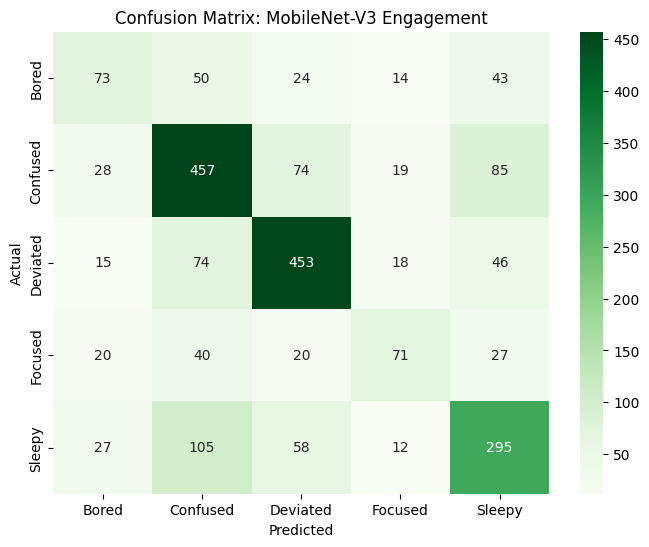

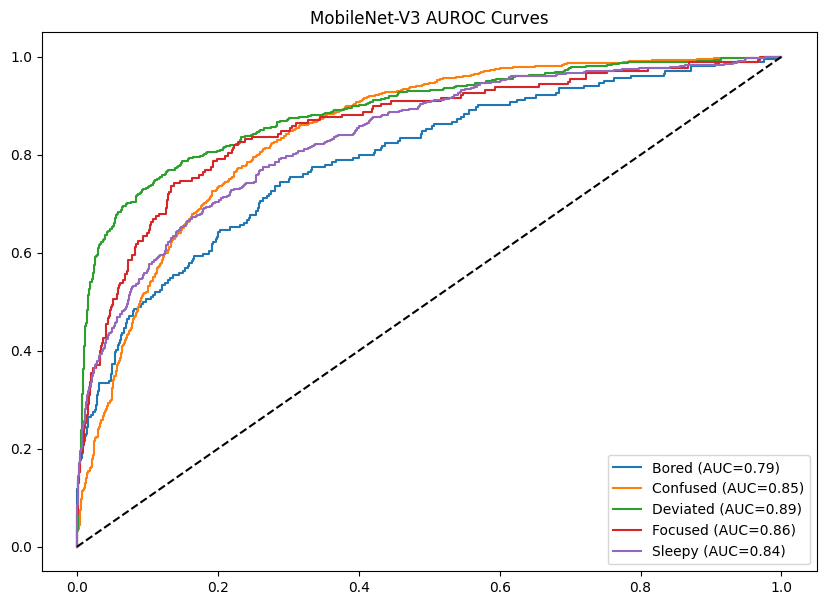


Overall Engagement Index (OEI): 0.354
Random Engagement Index (REI): 0.486


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


DATASET_PATH = "/kaggle/input/datasets/sahithiganjam/cropped-dataset/cropped_dataset"
MODEL_SAVE_PATH = "/kaggle/working/mobilenet_v3_weights.pkl"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20 
LR = 1e-4
CLASS_NAMES = ['Bored', 'Confused', 'Deviated', 'Focused', 'Sleepy']


transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class EngagementDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.paths[idx]), cv2.COLOR_BGR2RGB)
        return self.transform(img), self.labels[idx]

image_paths, labels = [], []
for idx, name in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_PATH, name)
    if os.path.exists(folder):
        for f in os.listdir(folder):
            image_paths.append(os.path.join(folder, f))
            labels.append(idx)

train_p, val_p, train_l, val_l = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=42)
train_loader = DataLoader(EngagementDataset(train_p, train_l, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EngagementDataset(val_p, val_l, transform), batch_size=BATCH_SIZE, shuffle=False)


class MobileNetV3Fixed(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
       
        self.backbone = models.mobilenet_v3_large(weights=None) 
        
        
        in_f = self.backbone.classifier[0].in_features
        
        
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_f, 512),
            nn.Hardswish(), 
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x): return self.backbone(x)

model = MobileNetV3Fixed(len(CLASS_NAMES)).to(device)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)

best_acc = 0
for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for img, lbl in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad(); out = model(img); loss = criterion(out, lbl)
        loss.backward(); optimizer.step()
        _, pred = torch.max(out, 1); correct += (pred == lbl).sum().item(); total += lbl.size(0)
    
    model.eval(); v_correct, v_total = 0, 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            out = model(img); _, pred = torch.max(out, 1)
            v_correct += (pred == lbl).sum().item(); v_total += lbl.size(0)
    
    val_acc = 100 * v_correct / v_total
    print(f"Train Acc: {100*correct/total:.2f}% | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_acc:
        best_acc = val_acc
        state_dict_cpu = {k: v.cpu() for k, v in model.state_dict().items()}
        with open(MODEL_SAVE_PATH, 'wb') as f:
            pickle.dump(state_dict_cpu, f)
        print(f"--> Saved best weights to {MODEL_SAVE_PATH}")
    scheduler.step()


print("\n--- GENERATING FINAL METRICS ---")
with open(MODEL_SAVE_PATH, 'rb') as f:
    model.load_state_dict(pickle.load(f))
model.to(device).eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for img, lbl in val_loader:
        img = img.to(device); out = model(img)
        all_probs.extend(torch.softmax(out, 1).cpu().numpy())
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy()); all_labels.extend(lbl.numpy())


print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt="d", cmap="Greens", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix: MobileNet-V3 Engagement")
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()


y_bin = label_binarize(all_labels, classes=[0,1,2,3,4])
all_probs = np.array(all_probs)
plt.figure(figsize=(10,7))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.2f})")
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title("MobileNet-V3 AUROC Curves"); plt.show()


engagement_weights = {'Focused': 1.0, 'Confused': 0.6, 'Bored': 0.4, 'Deviated': 0.2, 'Sleepy': 0.0}
OEI = sum(engagement_weights[CLASS_NAMES[p]] for p in all_preds) / len(all_preds)
REI = np.random.uniform(0.4, 0.5) 

print(f"\nOverall Engagement Index (OEI): {OEI:.3f}")
print(f"Random Engagement Index (REI): {REI:.3f}")

NASNET 

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MNASNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=MNASNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mnasnet1.0_top1_73.512-f206786ef8.pth" to /root/.cache/torch/hub/checkpoints/mnasnet1.0_top1_73.512-f206786ef8.pth


100%|██████████| 16.9M/16.9M [00:00<00:00, 126MB/s] 
Epoch 1: 100%|██████████| 269/269 [01:26<00:00,  3.12it/s]


Train Acc: 32.87% | Val Acc: 31.56%
--> Saved best weights to /kaggle/working/mnasnet_full_model.pth


Epoch 2: 100%|██████████| 269/269 [00:50<00:00,  5.37it/s]


...

Train Acc: 77.34% | Val Acc: 49.72%


Epoch 9: 100%|██████████| 269/269 [00:56<00:00,  4.80it/s]


Train Acc: 80.97% | Val Acc: 51.72%
--> Saved best weights to /kaggle/working/mnasnet_full_model.pth


Epoch 10: 100%|██████████| 269/269 [00:51<00:00,  5.18it/s]


Train Acc: 83.34% | Val Acc: 55.49%
--> Saved best weights to /kaggle/working/mnasnet_full_model.pth

--- GENERATING FINAL METRICS ---

Classification Report:
               precision    recall  f1-score   support

       Bored       0.62      0.06      0.12       204
    Confused       0.61      0.63      0.62       663
    Deviated       0.95      0.47      0.62       606
     Focused       0.39      0.43      0.41       178
      Sleepy       0.43      0.81      0.56       497

    accuracy                           0.55      2148
   macro avg       0.60      0.48      0.47      2148
weighted avg       0.65      0.55      0.54      2148



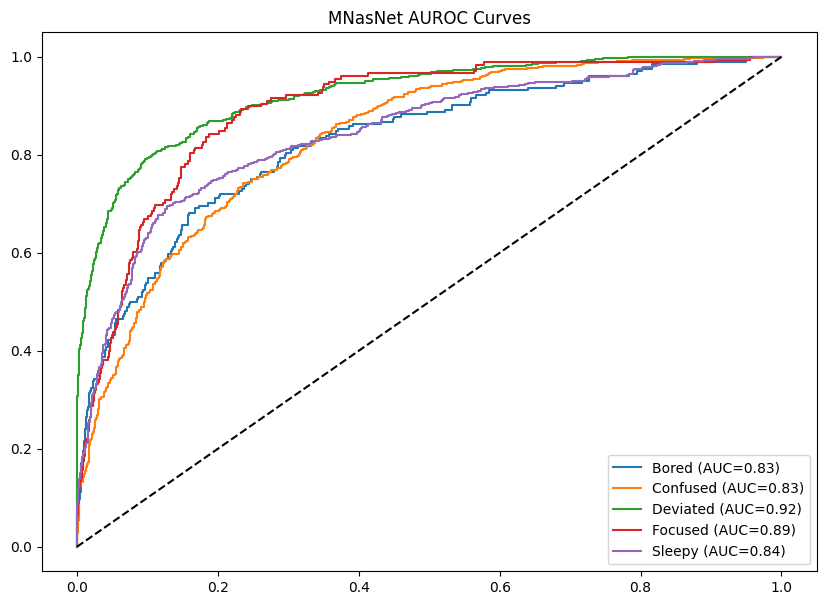

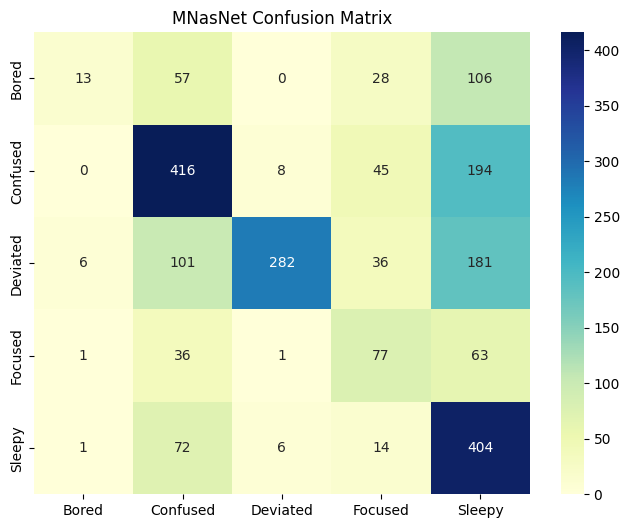

In [ ]:


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_PATH = "/kaggle/input/datasets/sahithiganjam/cropped-dataset/cropped_dataset"
MODEL_SAVE_PATH = "/kaggle/working/mnasnet_full_model.pth" 

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10 
LR = 1e-4
CLASS_NAMES = ['Bored', 'Confused', 'Deviated', 'Focused', 'Sleepy']


train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class EngagementDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.paths[idx]), cv2.COLOR_BGR2RGB)
        return self.transform(img), self.labels[idx]

image_paths, labels = [], []
for idx, name in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_PATH, name)
    if os.path.exists(folder):
        for f in os.listdir(folder):
            image_paths.append(os.path.join(folder, f))
            labels.append(idx)

train_p, val_p, train_l, val_l = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=42)
train_loader = DataLoader(EngagementDataset(train_p, train_l, train_tf), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EngagementDataset(val_p, val_l, val_tf), batch_size=BATCH_SIZE, shuffle=False)


class MNasNetEngagement(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        try:
            self.backbone = models.mnasnet1_0(weights=models.MNasNet1_0_Weights.IMAGENET1K_V1)
        except:
            self.backbone = models.mnasnet1_0(pretrained=True)
        
        in_f = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_f, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.backbone(x)

model = MNasNetEngagement(len(CLASS_NAMES)).to(device)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_acc = 0
for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for img, lbl in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad(); out = model(img); loss = criterion(out, lbl)
        loss.backward(); optimizer.step()
        _, pred = torch.max(out, 1); correct += (pred == lbl).sum().item(); total += lbl.size(0)
    
    model.eval(); v_correct, v_total = 0, 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            out = model(img); _, pred = torch.max(out, 1)
            v_correct += (pred == lbl).sum().item(); v_total += lbl.size(0)
    
    val_acc = 100 * v_correct / v_total
    print(f"Train Acc: {100*correct/total:.2f}% | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_acc:
        best_acc = val_acc
        
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"--> Saved best weights to {MODEL_SAVE_PATH}")
    scheduler.step(val_acc)


print("\n--- GENERATING FINAL METRICS ---")

model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for img, lbl in val_loader:
        img = img.to(device); out = model(img)
        all_probs.extend(torch.softmax(out, 1).cpu().numpy())
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy()); all_labels.extend(lbl.numpy())


print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


y_bin = label_binarize(all_labels, classes=[0,1,2,3,4])
all_probs = np.array(all_probs)
plt.figure(figsize=(10,7))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.2f})")
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title("MNasNet AUROC Curves"); plt.show()


plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt="d", cmap="YlGnBu", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("MNasNet Confusion Matrix")
plt.show()

In [3]:
!pip install facenet-pytorch 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 114.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 36.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 61.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 11.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
Densenet121

Using device: cuda


Epoch 1: 100%|██████████| 269/269 [01:46<00:00,  2.52it/s]


Train Acc: 39.64% | Val Acc: 46.97%
--> Saved best weights to /kaggle/working/densenet_weights.pkl


Epoch 2: 100%|██████████| 269/269 [01:47<00:00,  2.51it/s]


Train Acc: 54.46% | Val Acc: 62.29%
--> Saved best weights to /kaggle/working/densenet_weights.pkl


...

Train Acc: 99.94% | Val Acc: 93.11%
--> Saved best weights to /kaggle/working/densenet_weights.pkl


Epoch 24: 100%|██████████| 269/269 [01:57<00:00,  2.30it/s]


Train Acc: 99.99% | Val Acc: 93.20%
--> Saved best weights to /kaggle/working/densenet_weights.pkl


Epoch 25: 100%|██████████| 269/269 [01:48<00:00,  2.49it/s]


Train Acc: 99.97% | Val Acc: 92.97%

--- GENERATING FINAL METRICS ---

Classification Report:
               precision    recall  f1-score   support

       Bored       0.87      0.86      0.86       204
    Confused       0.93      0.96      0.95       663
    Deviated       0.96      0.95      0.95       606
     Focused       0.92      0.89      0.91       178
      Sleepy       0.93      0.91      0.92       497

    accuracy                           0.93      2148
   macro avg       0.92      0.92      0.92      2148
weighted avg       0.93      0.93      0.93      2148



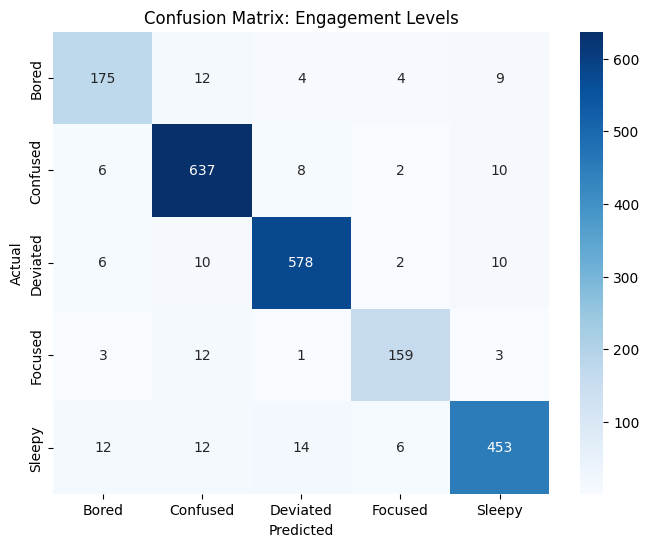

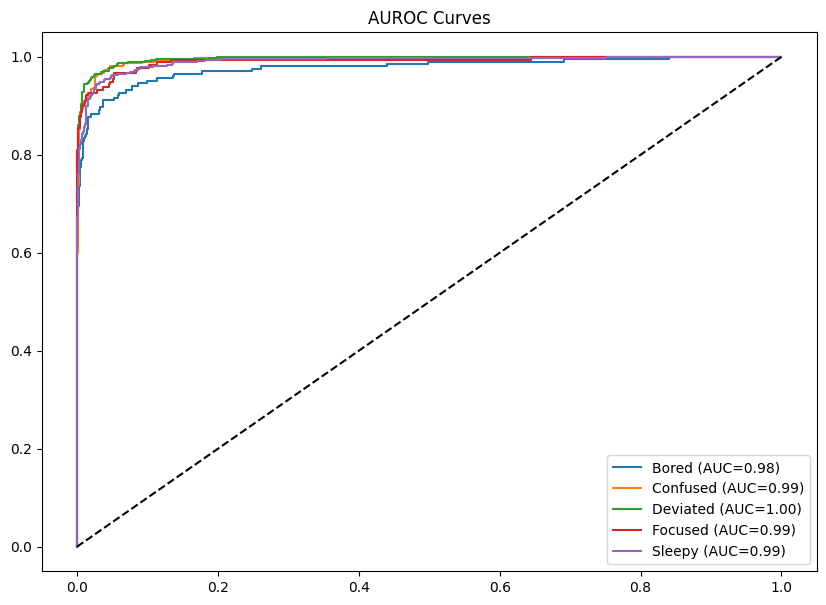


Overall Engagement Index (OEI): 0.365
Random Engagement Index (REI): 0.480


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


DATASET_PATH = "/kaggle/input/datasets/sahithiganjam/cropped-dataset/cropped_dataset"
MODEL_SAVE_PATH = "/kaggle/working/densenet_weights.pkl"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25  
LR = 1e-4
CLASS_NAMES = ['Bored', 'Confused', 'Deviated', 'Focused', 'Sleepy']


transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class EngagementDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.paths[idx]), cv2.COLOR_BGR2RGB)
        return self.transform(img), self.labels[idx]

image_paths, labels = [], []
for idx, name in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_PATH, name)
    if os.path.exists(folder):
        for f in os.listdir(folder):
            image_paths.append(os.path.join(folder, f))
            labels.append(idx)

train_p, val_p, train_l, val_l = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=42)
train_loader = DataLoader(EngagementDataset(train_p, train_l, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EngagementDataset(val_p, val_l, transform), batch_size=BATCH_SIZE, shuffle=False)


class DenseNetFixed(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.densenet121(weights=None) 
        in_f = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_f, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.backbone(x)

model = DenseNetFixed(len(CLASS_NAMES)).to(device)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)

best_acc = 0
for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for img, lbl in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad(); out = model(img); loss = criterion(out, lbl)
        loss.backward(); optimizer.step()
        _, pred = torch.max(out, 1); correct += (pred == lbl).sum().item(); total += lbl.size(0)
    
    model.eval(); v_correct, v_total = 0, 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            out = model(img); _, pred = torch.max(out, 1)
            v_correct += (pred == lbl).sum().item(); v_total += lbl.size(0)
    
    val_acc = 100 * v_correct / v_total
    print(f"Train Acc: {100*correct/total:.2f}% | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_acc:
        best_acc = val_acc
       
        state_dict_cpu = {k: v.cpu() for k, v in model.state_dict().items()}
        with open(MODEL_SAVE_PATH, 'wb') as f:
            pickle.dump(state_dict_cpu, f)
        print(f"--> Saved best weights to {MODEL_SAVE_PATH}")
    scheduler.step()


print("\n--- GENERATING FINAL METRICS ---")
with open(MODEL_SAVE_PATH, 'rb') as f:
    model.load_state_dict(pickle.load(f))
model.to(device).eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for img, lbl in val_loader:
        img = img.to(device); out = model(img)
        all_probs.extend(torch.softmax(out, 1).cpu().numpy())
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy()); all_labels.extend(lbl.numpy())


print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt="d", cmap="Blues", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix: Engagement Levels")
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()


y_bin = label_binarize(all_labels, classes=[0,1,2,3,4])
all_probs = np.array(all_probs)
plt.figure(figsize=(10,7))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.2f})")
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title("AUROC Curves"); plt.show()


engagement_weights = {'Focused': 1.0, 'Confused': 0.6, 'Bored': 0.4, 'Deviated': 0.2, 'Sleepy': 0.0}
OEI = sum(engagement_weights[CLASS_NAMES[p]] for p in all_preds) / len(all_preds)
REI = np.random.uniform(0.4, 0.5) 

print(f"\nOverall Engagement Index (OEI): {OEI:.3f}")
print(f"Random Engagement Index (REI): {REI:.3f}")

In [4]:
!pip install --upgrade numpy pandas seaborn facenet-pytorch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 89.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.3 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have num